This litle demonstration is based on the one you can find in the [official documentation](https://facebook.github.io/prophet/docs/quick_start.html#python-api)

In [1]:
import pandas as pd
from prophet import Prophet

df = pd.read_csv('https://raw.githubusercontent.com/facebook/prophet/main/examples/example_wp_log_peyton_manning.csv')
df

,ds,y
0,2007-12-10,9.590761
1,2007-12-11,8.519590
2,2007-12-12,8.183677
3,2007-12-13,8.072467
4,2007-12-14,7.893572
...,...,...
2900,2016-01-16,7.817223
2901,2016-01-17,9.273878
2902,2016-01-18,10.333775
2903,2016-01-19,9.125871


<Axes: xlabel='ds'>

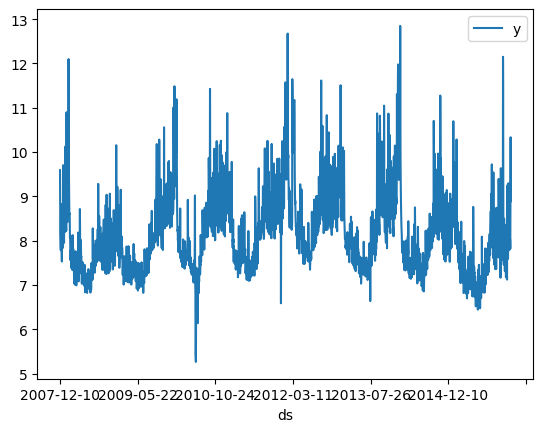

In [2]:
df.plot(x='ds', y='y', kind='line')

In [3]:
m = Prophet()
m.fit(df)

01:16:58 - cmdstanpy - INFO - Chain [1] start processing
01:16:58 - cmdstanpy - INFO - Chain [1] done processing


In [4]:
future = m.make_future_dataframe(periods=365)
future

,ds
0,2007-12-10
1,2007-12-11
2,2007-12-12
3,2007-12-13
4,2007-12-14
...,...
3265,2017-01-15
3266,2017-01-16
3267,2017-01-17
3268,2017-01-18


In [5]:
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]


,ds,yhat,yhat_lower,yhat_upper
0,2007-12-10,8.844654,8.261477,9.474585
1,2007-12-11,8.593185,7.953157,9.202670
2,2007-12-12,8.389000,7.750191,9.004373
3,2007-12-13,8.366914,7.770786,8.968256
4,2007-12-14,8.354877,7.748795,8.977774
...,...,...,...,...
3265,2017-01-15,8.210119,7.441436,8.927213
3266,2017-01-16,8.535144,7.764947,9.280150
3267,2017-01-17,8.322571,7.537982,8.998637
3268,2017-01-18,8.155201,7.379709,8.887080


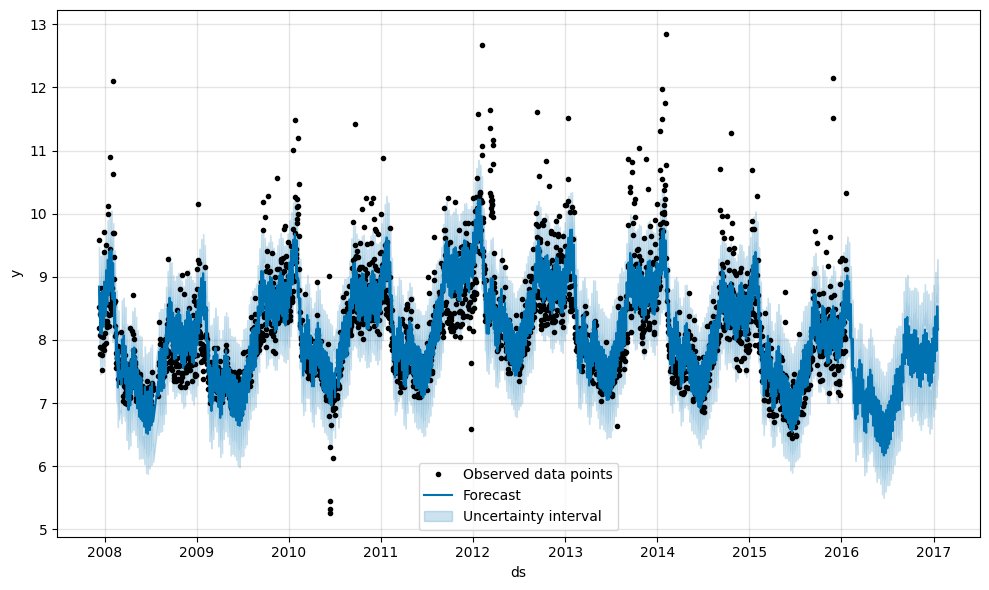

In [6]:
fig1 = m.plot(forecast, include_legend=True)

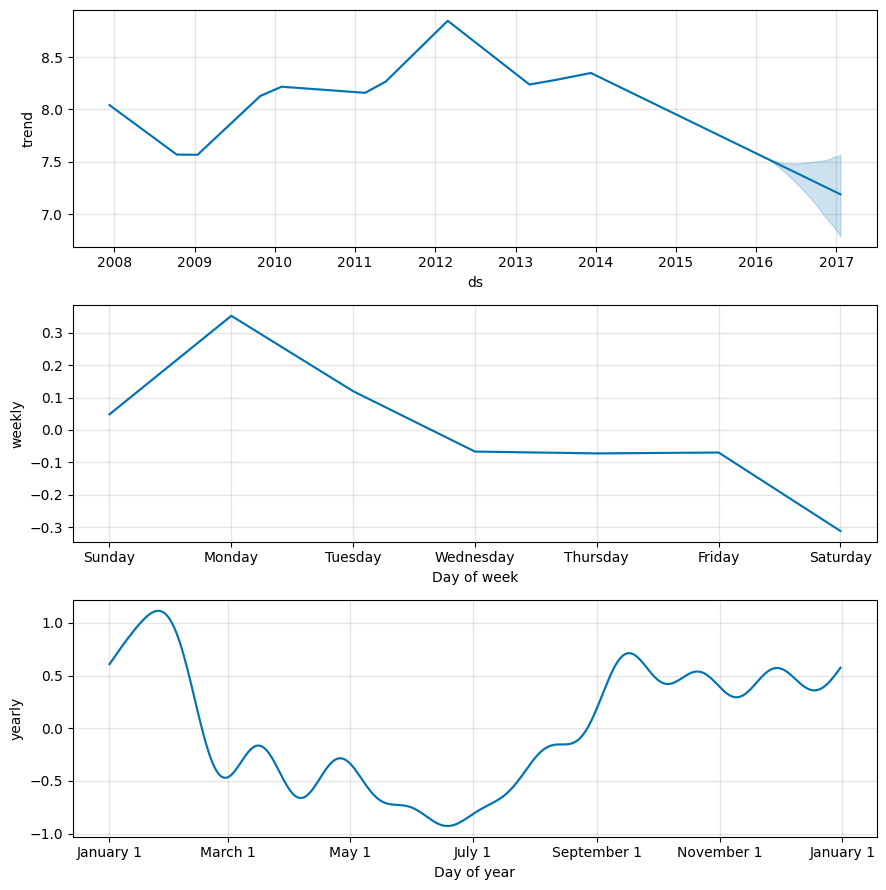

In [7]:
fig2 = m.plot_components(forecast)



In [8]:
from prophet.plot import plot_plotly, plot_components_plotly

plot_plotly(m, forecast, trend=True)